# OOHScout — UA Advanced Chapter 1 Adaptation

**Current scope:** F1 — Retargetable Study Area

This notebook resolves McLennan County, projects it to a Texas metric CRS, validates its administrative area, plots it over Esri World Imagery, and caches the boundary as a GeoPackage. It does not generate IH-35 geometry or candidate sites yet.

**Sources:** [OpenStreetMap Nominatim](https://nominatim.openstreetmap.org/) for the boundary, [U.S. Census TIGERweb county record 48309](https://tigerweb.geo.census.gov/tigerwebmain/Files/acs25/tigerweb_acs25_county_2020_tab20_tx.html) for the reference area, and Esri World Imagery for visual verification. The basemap requires internet access and is not persisted as project data.

## 1.1 Setting Up the Environment

Run JupyterLab from the repository root with `uv run jupyter lab`.

In [1]:
# F1 — imports used by the Chapter 1 study-area pattern
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox

print(f'geopandas {gpd.__version__}')
print(f'osmnx     {ox.__version__}')

geopandas 1.1.4
osmnx     2.1.1


## 1.2 The Study-Area Pattern

Keep the place and its matching metric CRS together. EPSG:4326 is used for OSM input; EPSG:32614 is used for McLennan measurements.

In [2]:
# F1 — retargetable study-area configuration
PLACE = 'McLennan County, Texas'
CRS_METRIC = 32614       # WGS 84 / UTM zone 14N, meters
CRS_GEOGRAPHIC = 4326    # WGS 84 longitude/latitude

# Census TIGER reports 2,685,056,036 m² land + 60,961,676 m² water.
REFERENCE_TOTAL_AREA_KM2 = 2746.0
AREA_TOLERANCE_PCT = 5.0

working_dir = Path.cwd().resolve()
repo_candidates = [working_dir, *working_dir.parents]
REPO_ROOT = next(
    (path for path in repo_candidates if (path / 'pyproject.toml').exists()),
    None,
)
assert REPO_ROOT is not None, 'Run this notebook from inside the repository.'

DATA_DIR = REPO_ROOT / 'backend' / 'data' / 'processed'
DATA_DIR.mkdir(parents=True, exist_ok=True)
place_slug = PLACE.split(',')[0].strip().lower().replace(' ', '_')
STUDY_AREA_PATH = DATA_DIR / f'{place_slug}_study_area.gpkg'

print(f'Study area : {PLACE}')
print(f'Metric CRS : EPSG:{CRS_METRIC}')
print(f'Cache path : {STUDY_AREA_PATH}')

Study area : McLennan County, Texas
Metric CRS : EPSG:32614
Cache path : C:\Users\nguye\Documents\billboardAI\backend\data\processed\mclennan_county_study_area.gpkg


Resolve the county once, then reuse the projected GeoPackage on later runs. The WGS 84 `admin_poly` is retained for future OSMnx queries; projected `study_area` owns metric calculations.

In [3]:
# F1 — resolve, project, and cache the administrative boundary
if STUDY_AREA_PATH.exists():
    admin_gdf_metric = gpd.read_file(STUDY_AREA_PATH, layer='study_area')
    admin_gdf = admin_gdf_metric.to_crs(epsg=CRS_GEOGRAPHIC)
    print('Loaded the cached study-area boundary.')
else:
    admin_gdf = ox.geocode_to_gdf(PLACE)
    admin_gdf_metric = admin_gdf.to_crs(epsg=CRS_METRIC)
    admin_gdf_metric.to_file(
        STUDY_AREA_PATH, layer='study_area', driver='GPKG'
    )
    print('Downloaded and cached the study-area boundary.')

admin_poly = admin_gdf.geometry.union_all()
study_area = admin_gdf_metric.geometry.union_all()

print(f'Boundary records : {len(admin_gdf):,}')
print(f'Geographic CRS   : {admin_gdf.crs}')
print(f'Metric CRS       : {admin_gdf_metric.crs}')

Loaded the cached study-area boundary.
Boundary records : 1
Geographic CRS   : EPSG:4326
Metric CRS       : EPSG:32614


Sanity checks are executable acceptance criteria. Stop here if any assertion fails.

In [4]:
# F1 — deterministic geometry and area sanity checks
assert len(admin_gdf) == 1, 'Expected one county record.'
assert admin_gdf.geometry.geom_type.isin(['Polygon', 'MultiPolygon']).all()
assert not admin_gdf.geometry.is_empty.any()
assert admin_gdf.geometry.is_valid.all()
assert admin_gdf_metric.crs.to_epsg() == CRS_METRIC
assert study_area.is_valid and not study_area.is_empty

area_km2 = study_area.area / 1_000_000
area_difference_pct = (
    abs(area_km2 - REFERENCE_TOTAL_AREA_KM2)
    / REFERENCE_TOTAL_AREA_KM2
    * 100
)

assert area_difference_pct <= AREA_TOLERANCE_PCT, (
    f'Area differs from the published reference by {area_difference_pct:.1f}%.'
)

print(f'Administrative area : {area_km2:,.1f} km²')
print(f'Reference difference: {area_difference_pct:.2f}%')
print('F1 geometry assertions passed.')

Administrative area : 2,747.3 km²
Reference difference: 0.05%
F1 geometry assertions passed.


The final acceptance check is visual: the red boundary must surround McLennan County in Central Texas.

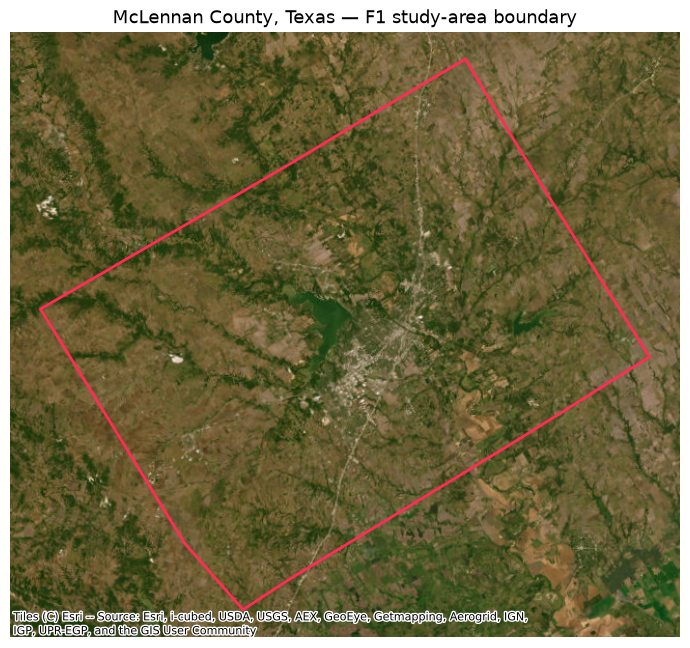

In [5]:
# F1 — plot the projected boundary on Esri World Imagery
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
admin_gdf_metric.plot(
    ax=ax, facecolor='none', edgecolor='#ff2d55', linewidth=2
)
cx.add_basemap(
    ax, crs=admin_gdf_metric.crs, source=cx.providers.Esri.WorldImagery
)
ax.set_title(f'{PLACE} — F1 study-area boundary', fontsize=13)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()

## F1 completion gate

Do not mark F1 complete until every assertion passes and you visually confirm the boundary. The next adaptation will use `admin_poly` to fetch IH-35 for F2. No eligibility determination or billboard recommendation is made in this notebook.